<a href="https://colab.research.google.com/github/Farhana-Najnin/Skin_Disease/blob/main/skinDiseaseUpdated.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


step2

In [ ]:
import os
import shutil
import torch

# Original source in Google Drive
SOURCE_DATASET_PATH = "/content/drive/MyDrive/Dataset/archive/IMG_CLASSES"

# Local runtime path (much faster)
LOCAL_DATASET_PATH = "/content/IMG_CLASSES"

# Copy only once
if not os.path.exists(LOCAL_DATASET_PATH):
    print("Copying dataset from Google Drive to local runtime...")
    shutil.copytree(SOURCE_DATASET_PATH, LOCAL_DATASET_PATH)
    print("Dataset copied successfully!")
else:
    print("Dataset already exists in local runtime.")

# Use local path from now on
DATASET_PATH = LOCAL_DATASET_PATH

# Speed optimization
torch.backends.cudnn.benchmark = True

print("Using dataset path:", DATASET_PATH)
print("Classes:", os.listdir(DATASET_PATH))


Dataset already exists in local runtime.
Using dataset path: /content/IMG_CLASSES
Classes: ['6. Benign Keratosis-like Lesions (BKL) 2624', '4. Basal Cell Carcinoma (BCC) 3323', '7. Psoriasis pictures Lichen Planus and related diseases - 2k', '9. Tinea Ringworm Candidiasis and other Fungal Infections - 1.7k', '1. Eczema 1677', '8. Seborrheic Keratoses and other Benign Tumors - 1.8k', '2. Melanoma 15.75k', '10. Warts Molluscum and other Viral Infections - 2103', '3. Atopic Dermatitis - 1.25k', '5. Melanocytic Nevi (NV) - 7970']


In [ ]:
import os

print(os.listdir(DATASET_PATH))

['6. Benign Keratosis-like Lesions (BKL) 2624', '4. Basal Cell Carcinoma (BCC) 3323', '7. Psoriasis pictures Lichen Planus and related diseases - 2k', '9. Tinea Ringworm Candidiasis and other Fungal Infections - 1.7k', '1. Eczema 1677', '8. Seborrheic Keratoses and other Benign Tumors - 1.8k', '2. Melanoma 15.75k', '10. Warts Molluscum and other Viral Infections - 2103', '3. Atopic Dermatitis - 1.25k', '5. Melanocytic Nevi (NV) - 7970']


step3

In [ ]:
import os

original_classes = sorted(os.listdir(DATASET_PATH))

clean_classes = []
class_map = {}

for cls in original_classes:
    clean_name = cls.split('.', 1)[-1]  # remove numbering
    clean_name = clean_name.split('-')[0].strip()  # remove counts

    clean_classes.append(clean_name)
    class_map[cls] = clean_name

print(class_map)

{'1. Eczema 1677': 'Eczema 1677', '10. Warts Molluscum and other Viral Infections - 2103': 'Warts Molluscum and other Viral Infections', '2. Melanoma 15.75k': 'Melanoma 15.75k', '3. Atopic Dermatitis - 1.25k': 'Atopic Dermatitis', '4. Basal Cell Carcinoma (BCC) 3323': 'Basal Cell Carcinoma (BCC) 3323', '5. Melanocytic Nevi (NV) - 7970': 'Melanocytic Nevi (NV)', '6. Benign Keratosis-like Lesions (BKL) 2624': 'Benign Keratosis', '7. Psoriasis pictures Lichen Planus and related diseases - 2k': 'Psoriasis pictures Lichen Planus and related diseases', '8. Seborrheic Keratoses and other Benign Tumors - 1.8k': 'Seborrheic Keratoses and other Benign Tumors', '9. Tinea Ringworm Candidiasis and other Fungal Infections - 1.7k': 'Tinea Ringworm Candidiasis and other Fungal Infections'}


step 4

In [ ]:
import pandas as pd

data = []

for folder in original_classes:
    folder_path = os.path.join(DATASET_PATH, folder)
    label = class_map[folder]

    for img in os.listdir(folder_path):
        img_path = os.path.join(folder_path, img)
        data.append([img_path, label])

df = pd.DataFrame(data, columns=["image_path", "label"])

print("Total images:", len(df))
df.head()

Total images: 27153


,image_path,label
0,/content/IMG_CLASSES/1. Eczema 1677/v-eczema-l...,Eczema 1677
1,/content/IMG_CLASSES/1. Eczema 1677/t-eczema-s...,Eczema 1677
2,/content/IMG_CLASSES/1. Eczema 1677/t-eczema-n...,Eczema 1677
3,/content/IMG_CLASSES/1. Eczema 1677/t-eczema-h...,Eczema 1677
4,/content/IMG_CLASSES/1. Eczema 1677/v-eczema-f...,Eczema 1677


step 5

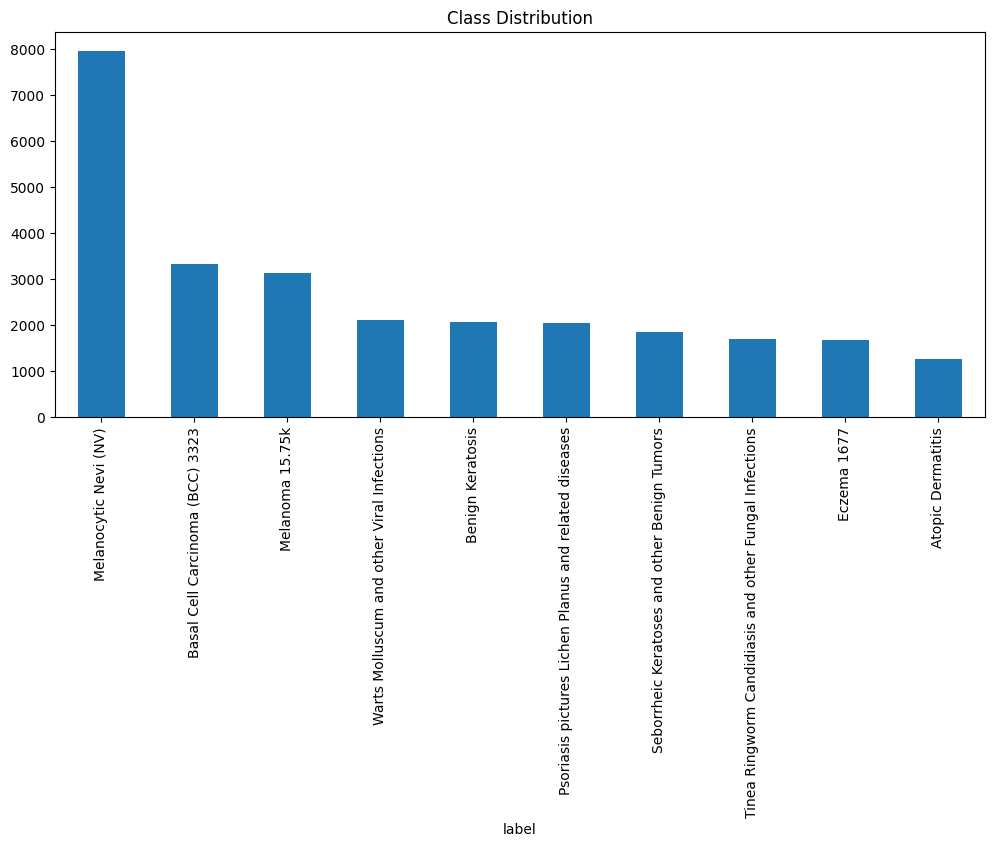

In [ ]:
import matplotlib.pyplot as plt

df['label'].value_counts().plot(kind='bar', figsize=(12,5))
plt.title("Class Distribution")
plt.show()

step 6

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['label_encoded'] = le.fit_transform(df['label'])

num_classes = len(le.classes_)
print("Number of classes:", num_classes)

Number of classes: 10


In [ ]:
import json

with open("/content/class_names.json", "w") as f:
    json.dump(list(le.classes_), f)

STEP 7

In [ ]:
from sklearn.model_selection import train_test_split

train_df, temp_df = train_test_split(
    df, test_size=0.3, stratify=df['label_encoded'], random_state=42
)

val_df, test_df = train_test_split(
    temp_df, test_size=0.5, stratify=temp_df['label_encoded'], random_state=42
)

print("Train:", len(train_df))
print("Val:", len(val_df))
print("Test:", len(test_df))

Train: 19007
Val: 4073
Test: 4073


STEP 8 — Image Transformations

In [ ]:
import torchvision.transforms as transforms

IMAGE_SIZE = 224

train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(12),
    transforms.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.15, hue=0.02),
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05), scale=(0.95, 1.05)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
    transforms.RandomErasing(p=0.15, scale=(0.02, 0.08), ratio=(0.3, 3.3))
])

val_test_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

STEP 9

In [ ]:
from torch.utils.data import Dataset
from PIL import Image

class SkinDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_path = self.df.loc[idx, 'image_path']
        label = self.df.loc[idx, 'label_encoded']

        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, label

STEP 10

In [ ]:
import torch
from torch.utils.data import DataLoader, WeightedRandomSampler

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# class weights from TRAIN SET only
class_counts = train_df['label_encoded'].value_counts().sort_index().values
class_weights = 1.0 / torch.tensor(class_counts, dtype=torch.float)
class_weights = class_weights / class_weights.sum()
class_weights = class_weights.to(device)

# sample weights for each training sample
sample_weights = train_df['label_encoded'].map(
    lambda x: 1.0 / class_counts[x]
).values
sample_weights = torch.DoubleTensor(sample_weights)

train_sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

train_dataset = SkinDataset(train_df, transform=train_transform)
val_dataset = SkinDataset(val_df, transform=val_test_transform)
test_dataset = SkinDataset(test_df, transform=val_test_transform)

BATCH_SIZE = 64  # if CUDA OOM happens, change to 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    sampler=train_sampler,
    num_workers=4,
    pin_memory=True,
    persistent_workers=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=4,
    pin_memory=True,
    persistent_workers=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=4,
    pin_memory=True,
    persistent_workers=True
)

print("Dataloaders ready ✅")
print("Batch size:", BATCH_SIZE)

Dataloaders ready ✅
Batch size: 64


In [ ]:
from torch.utils.data import DataLoader

train_dataset = SkinDataset(train_df, transform=train_transform)
val_dataset = SkinDataset(val_df, transform=val_test_transform)
test_dataset = SkinDataset(test_df, transform=val_test_transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2)

print("Dataloaders ready ✅")

Dataloaders ready ✅


STEP 11

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models
from tqdm import tqdm

STEP 12


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


STEP 13-14

In [ ]:
from torchvision import models
import torch.nn as nn

model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)

# Freeze all backbone layers first
for param in model.features.parameters():
    param.requires_grad = False

# Replace classifier
num_features = model.classifier[1].in_features
model.classifier[1] = nn.Linear(num_features, num_classes)

model = model.to(device)

STEP 15

In [ ]:
criterion = nn.CrossEntropyLoss(weight=class_weights)

STEP 16

In [ ]:
import torch.nn as nn
import torch.optim as optim

criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.1)

optimizer = optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-3,
    weight_decay=1e-4
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.3,
    patience=1
)

STEP 17

In [ ]:
from tqdm import tqdm
import torch

scaler = torch.amp.GradScaler('cuda')

def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0.0
    correct = 0
    total = 0

    loop = tqdm(loader, desc="Training", leave=False)

    for images, labels in loop:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast('cuda'):
            outputs = model(images)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item()
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

        loop.set_postfix(
            loss=f"{loss.item():.4f}",
            acc=f"{correct/total:.4f}"
        )

    return total_loss / len(loader), correct / total

STEP 18

In [ ]:
def evaluate(model, loader, criterion):
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            with torch.amp.autocast('cuda'):
                outputs = model(images)
                loss = criterion(outputs, labels)

            total_loss += loss.item()
            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    return total_loss / len(loader), correct / total

STEP 19

In [ ]:
import torch.optim as optim

# Load best phase-1 model
model.load_state_dict(torch.load("/content/best_model_phase1.pth"))

# Unfreeze the last several feature blocks instead of only the last tiny part
for param in model.features.parameters():
    param.requires_grad = False

for param in model.features[5:].parameters():
    param.requires_grad = True

# also keep classifier trainable
for param in model.classifier.parameters():
    param.requires_grad = True

optimizer = optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-4,
    weight_decay=1e-4
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.3,
    patience=1
)

best_val_acc = 0.0
patience = 3
patience_counter = 0

EPOCHS_FINE = 6

for epoch in range(EPOCHS_FINE):
    print(f"\nFine-tuning Epoch {epoch+1}/{EPOCHS_FINE}")

    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion)
    val_loss, val_acc = evaluate(model, val_loader, criterion)

    scheduler.step(val_loss)

    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        patience_counter = 0
        torch.save(model.state_dict(), "/content/best_model.pth")
        print("✅ Final best model saved")
    else:
        patience_counter += 1
        print(f"No improvement. Patience: {patience_counter}/{patience}")

        if patience_counter >= patience:
            print("⏹ Early stopping triggered")
            break


Fine-tuning Epoch 1/6


Train Loss: 1.4303 | Train Acc: 0.6743
Val Loss: 1.3190 | Val Acc: 0.7289
✅ Final best model saved

Fine-tuning Epoch 2/6


Train Loss: 1.2717 | Train Acc: 0.7452
Val Loss: 1.2357 | Val Acc: 0.7761
✅ Final best model saved

Fine-tuning Epoch 3/6


Train Loss: 1.1761 | Train Acc: 0.7844
Val Loss: 1.2073 | Val Acc: 0.7979
✅ Final best model saved

Fine-tuning Epoch 4/6


Train Loss: 1.0975 | Train Acc: 0.8185
Val Loss: 1.1766 | Val Acc: 0.8053
✅ Final best model saved

Fine-tuning Epoch 5/6


Train Loss: 1.0450 | Train Acc: 0.8380
Val Loss: 1.1605 | Val Acc: 0.8073
✅ Final best model saved

Fine-tuning Epoch 6/6


Train Loss: 0.9857 | Train Acc: 0.8653
Val Loss: 1.1654 | Val Acc: 0.8173
✅ Final best model saved


New step after Step 19

STEP 21



In [ ]:
import torch

model.load_state_dict(torch.load("/content/best_model.pth"))
model.eval()

print("Best model loaded ✅")

Best model loaded ✅


STEP 22

In [ ]:
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        with torch.amp.autocast('cuda'):
            outputs = model(images)

        preds = outputs.argmax(dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

print("Test predictions collected ✅")

Test predictions collected ✅


STEP 23

In [ ]:
from sklearn.metrics import accuracy_score, classification_report

test_acc = accuracy_score(all_labels, all_preds)
print(f"Test Accuracy: {test_acc:.4f}")

report = classification_report(
    all_labels,
    all_preds,
    target_names=le.classes_,
    digits=4
)

print(report)

Test Accuracy: 0.8092
                                                        precision    recall  f1-score   support

                                     Atopic Dermatitis     0.4693    0.7672    0.5823       189
                       Basal Cell Carcinoma (BCC) 3323     0.9167    0.9056    0.9111       498
                                      Benign Keratosis     0.6500    0.8750    0.7459       312
                                           Eczema 1677     0.7009    0.6508    0.6749       252
                                 Melanocytic Nevi (NV)     0.9747    0.8704    0.9196      1196
                                       Melanoma 15.75k     0.9455    0.9575    0.9515       471
 Psoriasis pictures Lichen Planus and related diseases     0.6911    0.5519    0.6137       308
          Seborrheic Keratoses and other Benign Tumors     0.6859    0.7726    0.7267       277
Tinea Ringworm Candidiasis and other Fungal Infections     0.7569    0.6471    0.6977       255
            Warts

STEP 24

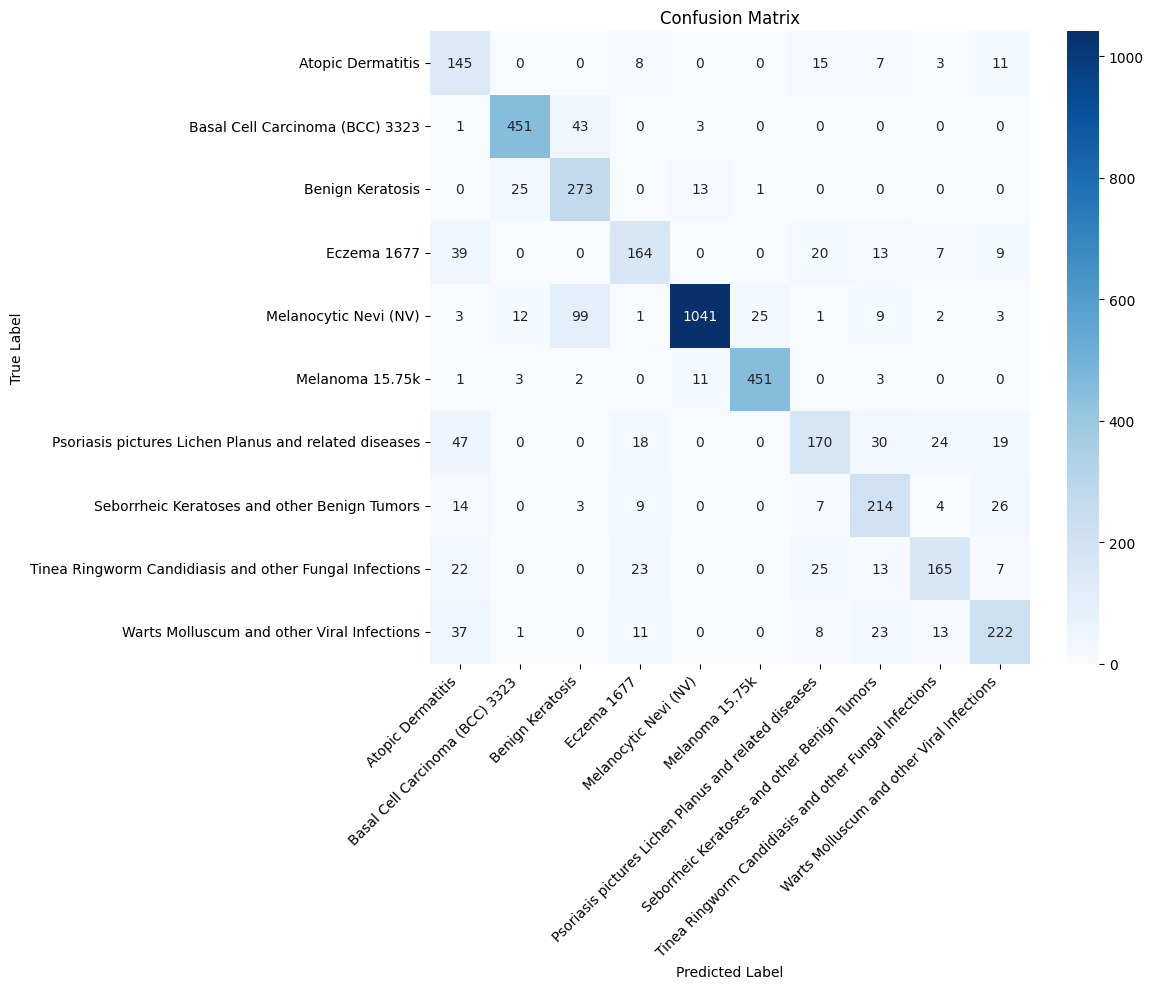

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=le.classes_,
            yticklabels=le.classes_)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

STEP 25

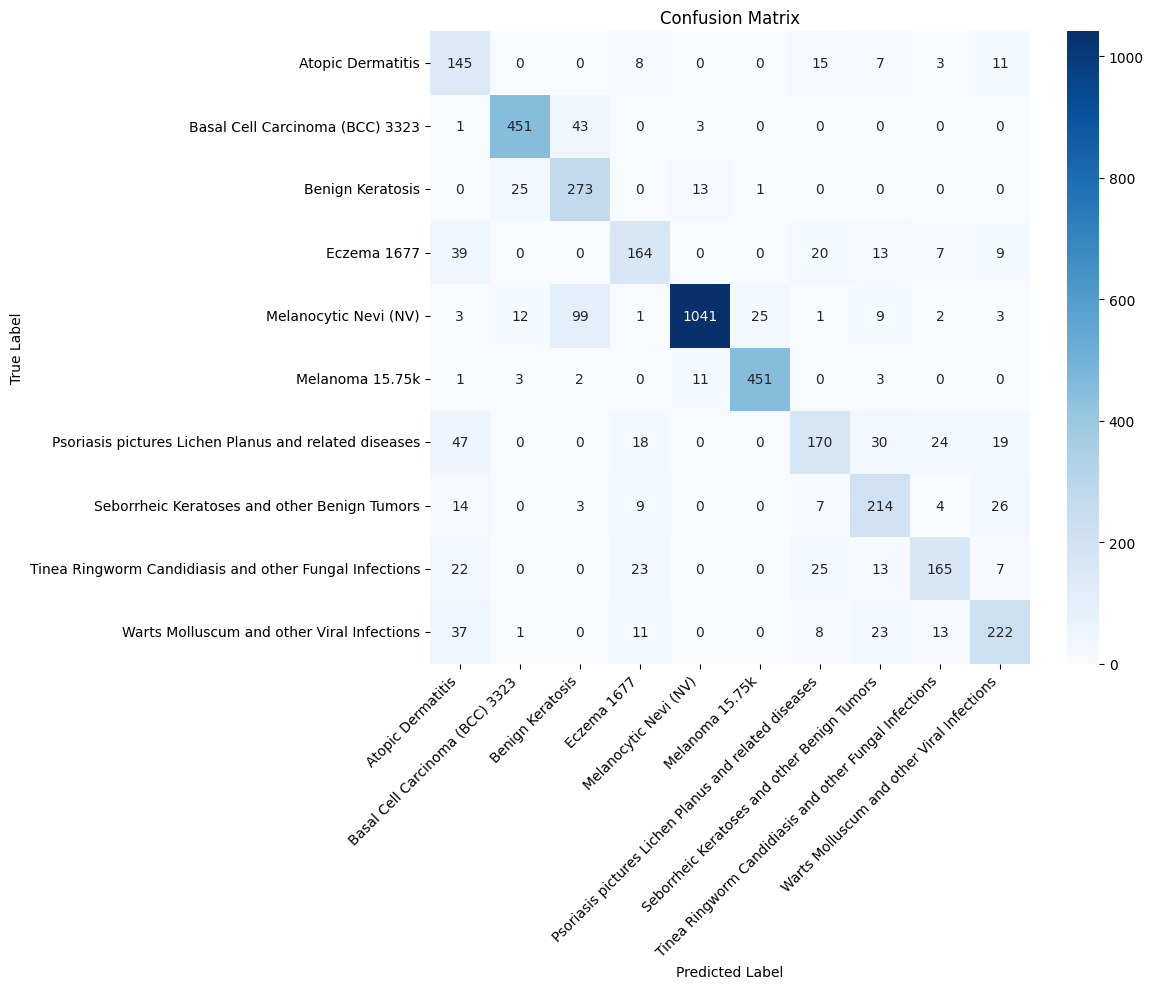

Confusion matrix saved ✅


In [ ]:
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=le.classes_,
            yticklabels=le.classes_)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig("/content/confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

print("Confusion matrix saved ✅")

STEP 26

In [ ]:
with open("/content/classification_report.txt", "w") as f:
    f.write(f"Test Accuracy: {test_acc:.4f}\n\n")
    f.write(report)

print("Classification report saved ✅")

Classification report saved ✅


STEP 27

In [ ]:
import pandas as pd

test_df_reset = test_df.reset_index(drop=True).copy()
test_df_reset["true_label"] = test_df_reset["label_encoded"].map(lambda x: le.classes_[x])
test_df_reset["pred_label"] = [le.classes_[p] for p in all_preds]
test_df_reset["correct"] = test_df_reset["true_label"] == test_df_reset["pred_label"]

test_df_reset.head()

,image_path,label,label_encoded,true_label,pred_label,correct
0,/content/IMG_CLASSES/5. Melanocytic Nevi (NV) ...,Melanocytic Nevi (NV),4,Melanocytic Nevi (NV),Melanocytic Nevi (NV),True
1,/content/IMG_CLASSES/3. Atopic Dermatitis - 1....,Atopic Dermatitis,0,Atopic Dermatitis,Atopic Dermatitis,True
2,/content/IMG_CLASSES/9. Tinea Ringworm Candidi...,Tinea Ringworm Candidiasis and other Fungal In...,8,Tinea Ringworm Candidiasis and other Fungal In...,Tinea Ringworm Candidiasis and other Fungal In...,True
3,/content/IMG_CLASSES/9. Tinea Ringworm Candidi...,Tinea Ringworm Candidiasis and other Fungal In...,8,Tinea Ringworm Candidiasis and other Fungal In...,Tinea Ringworm Candidiasis and other Fungal In...,True
4,/content/IMG_CLASSES/1. Eczema 1677/v-stasis-d...,Eczema 1677,3,Eczema 1677,Eczema 1677,True


STEP 28

In [ ]:
test_df_reset.to_csv("/content/test_predictions.csv", index=False)
print("Test predictions CSV saved ✅")

Test predictions CSV saved ✅


STEP 29

In [ ]:
correct_samples = test_df_reset[test_df_reset["correct"] == True].sample(5, random_state=42)
wrong_samples = test_df_reset[test_df_reset["correct"] == False].sample(5, random_state=42)

print("Correct predictions:")
display(correct_samples[["image_path", "true_label", "pred_label"]])

print("\nWrong predictions:")
display(wrong_samples[["image_path", "true_label", "pred_label"]])

Correct predictions:


,image_path,true_label,pred_label
3819,/content/IMG_CLASSES/4. Basal Cell Carcinoma (...,Basal Cell Carcinoma (BCC) 3323,Basal Cell Carcinoma (BCC) 3323
3901,/content/IMG_CLASSES/4. Basal Cell Carcinoma (...,Basal Cell Carcinoma (BCC) 3323,Basal Cell Carcinoma (BCC) 3323
2384,/content/IMG_CLASSES/4. Basal Cell Carcinoma (...,Basal Cell Carcinoma (BCC) 3323,Basal Cell Carcinoma (BCC) 3323
2410,/content/IMG_CLASSES/4. Basal Cell Carcinoma (...,Basal Cell Carcinoma (BCC) 3323,Basal Cell Carcinoma (BCC) 3323
2965,/content/IMG_CLASSES/5. Melanocytic Nevi (NV) ...,Melanocytic Nevi (NV),Melanocytic Nevi (NV)



Wrong predictions:


,image_path,true_label,pred_label
3000,/content/IMG_CLASSES/9. Tinea Ringworm Candidi...,Tinea Ringworm Candidiasis and other Fungal In...,Atopic Dermatitis
2799,/content/IMG_CLASSES/9. Tinea Ringworm Candidi...,Tinea Ringworm Candidiasis and other Fungal In...,Atopic Dermatitis
3231,/content/IMG_CLASSES/10. Warts Molluscum and o...,Warts Molluscum and other Viral Infections,Atopic Dermatitis
533,/content/IMG_CLASSES/10. Warts Molluscum and o...,Warts Molluscum and other Viral Infections,Seborrheic Keratoses and other Benign Tumors
3109,/content/IMG_CLASSES/7. Psoriasis pictures Lic...,Psoriasis pictures Lichen Planus and related d...,Eczema 1677


STEP 30

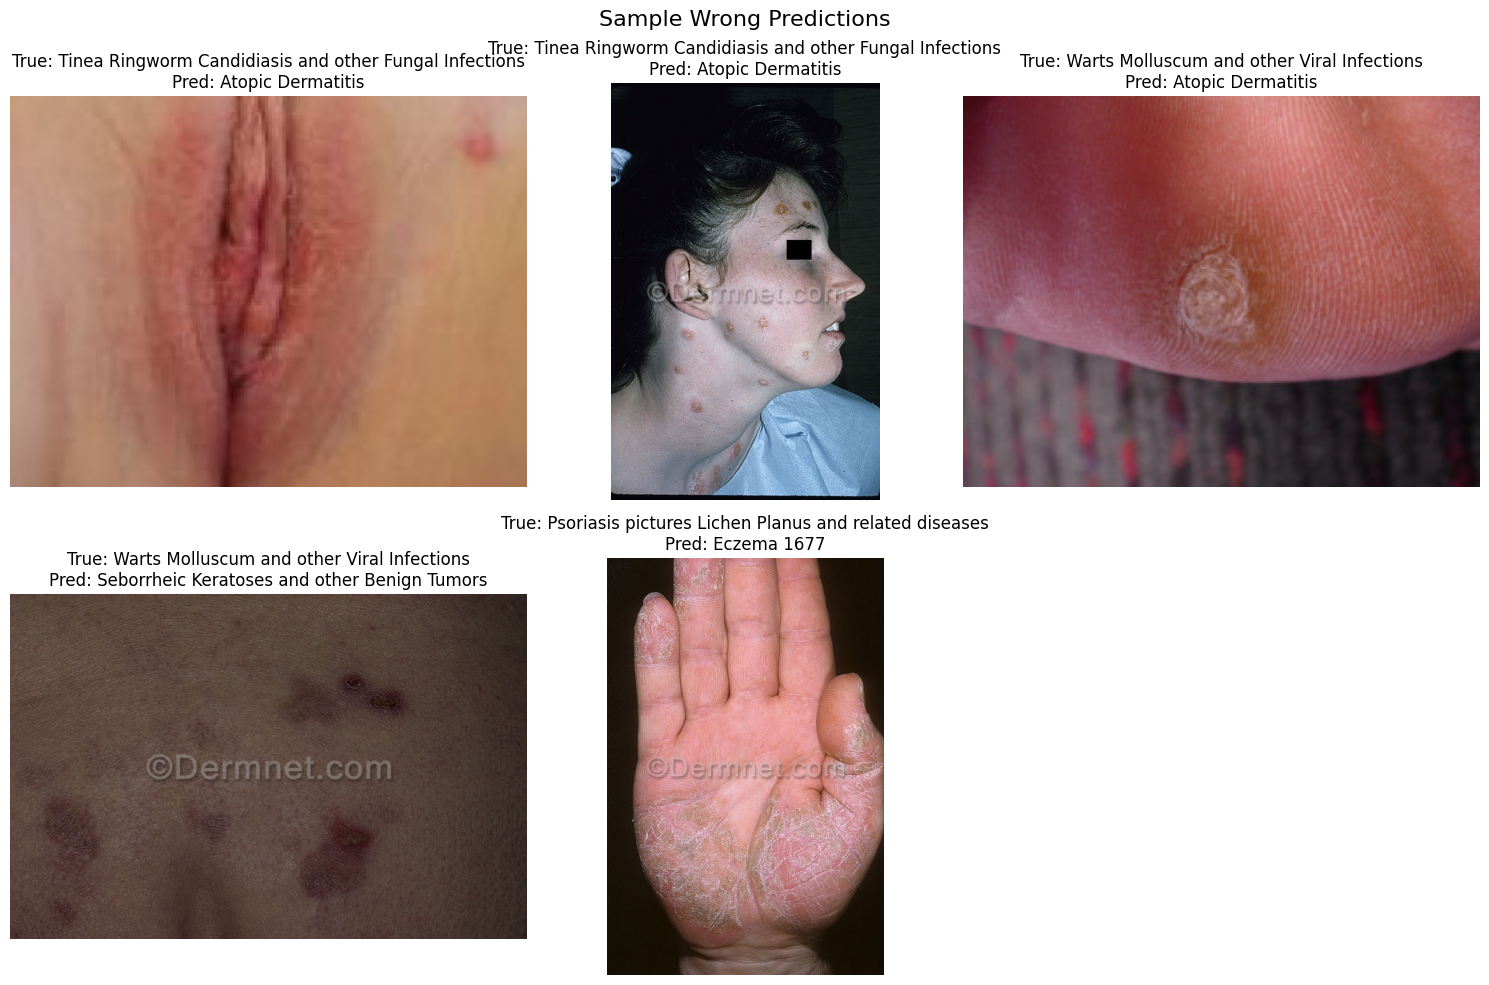

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt

def show_predictions(samples_df, title):
    plt.figure(figsize=(15, 10))
    for i, (_, row) in enumerate(samples_df.iterrows()):
        img = Image.open(row["image_path"]).convert("RGB")
        plt.subplot(2, 3, i+1)
        plt.imshow(img)
        plt.title(f"True: {row['true_label']}\nPred: {row['pred_label']}")
        plt.axis("off")
    plt.suptitle(title, fontsize=16)
    plt.tight_layout()
    plt.show()

# Show wrong samples
show_predictions(wrong_samples, "Sample Wrong Predictions")

STEP 31

In [ ]:
import json

class_names = list(le.classes_)

with open("/content/class_names.json", "w") as f:
    json.dump(class_names, f)

print("class_names.json saved ✅")
print(class_names)

class_names.json saved ✅
['Atopic Dermatitis', 'Basal Cell Carcinoma (BCC) 3323', 'Benign Keratosis', 'Eczema 1677', 'Melanocytic Nevi (NV)', 'Melanoma 15.75k', 'Psoriasis pictures Lichen Planus and related diseases', 'Seborrheic Keratoses and other Benign Tumors', 'Tinea Ringworm Candidiasis and other Fungal Infections', 'Warts Molluscum and other Viral Infections']


STEP 32

In [ ]:
import torchvision.transforms as transforms

IMAGE_SIZE = 224

inference_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

STEP 33

In [ ]:
from PIL import Image
import torch

def predict_single_image(image, model, class_names, transform, device):
    model.eval()

    if isinstance(image, str):
        image = Image.open(image).convert("RGB")
    else:
        image = image.convert("RGB")

    image_tensor = transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        with torch.amp.autocast('cuda'):
            outputs = model(image_tensor)
            probs = torch.softmax(outputs, dim=1)
            confidence, pred_idx = torch.max(probs, dim=1)

    predicted_class = class_names[pred_idx.item()]
    confidence_score = confidence.item()

    return {
        "disease": predicted_class,
        "confidence": round(confidence_score, 4)
    }

STEP 34

In [ ]:
sample_image_path = test_df_reset.iloc[0]["image_path"]

result = predict_single_image(
    sample_image_path,
    model,
    class_names,
    inference_transform,
    device
)

print(result)

{'disease': 'Melanocytic Nevi (NV)', 'confidence': 0.805}


STEP 35

In [ ]:
!pip install -q fastapi uvicorn python-multipart pyngrok nest-asyncio

STEP 36

In [ ]:
import os

os.environ["NGROK_AUTH_TOKEN"] = "3C9dcO6inJJIoSxTYNwgHBsD2Ie_7YHo7K8mpBpHvTjnikoZW"

print("NGROK token set successfully ✅")

NGROK token set successfully ✅


STEP 37

In [ ]:
def generate_recommendation(disease, confidence):
    advice_dict = {
        "Eczema": {
            "recommendations": "Keep the skin moisturized and avoid known irritants such as harsh soaps, detergents, or allergens.",
            "next_steps": "Consult a dermatologist if symptoms persist, spread, or become more severe.",
            "tips": "Use fragrance-free products, avoid scratching, and keep the skin hydrated."
        },
        "Melanoma": {
            "recommendations": "This prediction should be treated seriously. Monitor the lesion closely for changes in size, shape, or color.",
            "next_steps": "Consult a dermatologist as soon as possible for professional examination.",
            "tips": "Avoid sun exposure, use sunscreen, and do not ignore rapid skin changes."
        },
        "Atopic Dermatitis": {
            "recommendations": "Maintain regular skin hydration and avoid possible triggers such as harsh products or allergens.",
            "next_steps": "See a doctor if itching, redness, or irritation becomes severe.",
            "tips": "Use mild soap, moisturize often, and avoid scratching."
        },
        "Basal Cell Carcinoma (BCC)": {
            "recommendations": "Protect the skin from direct sun exposure and avoid UV damage.",
            "next_steps": "Consult a dermatologist for proper evaluation and treatment planning.",
            "tips": "Use sunscreen regularly and wear protective clothing outdoors."
        },
        "Melanocytic Nevi (NV)": {
            "recommendations": "These lesions should be monitored for unusual changes.",
            "next_steps": "Consult a dermatologist if the mole changes in color, size, or border.",
            "tips": "Track skin changes over time and avoid excessive sun exposure."
        },
        "Benign Keratosis-like Lesions (BKL)": {
            "recommendations": "These are often non-cancerous, but changes should still be monitored.",
            "next_steps": "Seek medical advice if the lesion becomes irritated or changes appearance.",
            "tips": "Avoid scratching and keep the area clean."
        },
        "Psoriasis pictures Lichen Planus and related diseases": {
            "recommendations": "Maintain a gentle skin-care routine and avoid possible triggers such as stress or harsh chemicals.",
            "next_steps": "Consult a dermatologist for proper diagnosis and long-term management.",
            "tips": "Keep skin moisturized and avoid irritating skin products."
        },
        "Seborrheic Keratoses and other Benign Tumors": {
            "recommendations": "These are generally benign but should still be observed for unusual changes.",
            "next_steps": "Consult a dermatologist if the lesion grows rapidly, bleeds, or becomes painful.",
            "tips": "Do not scratch or attempt to remove the lesion yourself."
        },
        "Tinea Ringworm Candidiasis and other Fungal Infections": {
            "recommendations": "Keep the affected area clean and dry to reduce fungal growth.",
            "next_steps": "Consult a healthcare provider for appropriate antifungal treatment.",
            "tips": "Do not share towels or personal items, and maintain good hygiene."
        },
        "Warts Molluscum and other Viral Infections": {
            "recommendations": "Avoid touching, scratching, or spreading the affected area.",
            "next_steps": "Consult a healthcare provider if the condition spreads or worsens.",
            "tips": "Maintain hygiene and avoid direct skin-to-skin spread."
        }
    }

    return advice_dict.get(disease, {
        "recommendations": f"The model predicts {disease} with confidence {confidence:.2f}. Maintain general skin care and avoid self-medication.",
        "next_steps": "Consult a dermatologist for a professional diagnosis.",
        "tips": "Monitor the area and avoid harsh skin-care products."
    })

STEP 38

In [ ]:
app_code = r'''
import io
import json
import re
import torch
from PIL import Image
from fastapi import FastAPI, UploadFile, File
from fastapi.responses import JSONResponse
from torchvision import models, transforms
import torch.nn as nn

app = FastAPI(title="Skin Disease Detection API")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

with open("/content/class_names.json", "r") as f:
    class_names = json.load(f)

num_classes = len(class_names)

model = models.efficientnet_b0(weights=None)
num_features = model.classifier[1].in_features
model.classifier[1] = nn.Linear(num_features, num_classes)

model.load_state_dict(torch.load("/content/best_model.pth", map_location=device))
model = model.to(device)
model.eval()

IMAGE_SIZE = 224
inference_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

def clean_label(label):
    label = re.sub(r'\d+', '', label)          # remove numbers
    label = re.sub(r'[_\-]+', ' ', label)      # replace _ and - with space
    label = re.sub(r'\s+', ' ', label)         # remove extra spaces
    label = label.strip()
    return label.title()

def generate_llm_recommendation(disease, confidence):
    advice_dict = {
        "Eczema": {
            "recommendations": "Keep the skin moisturized and avoid known irritants such as harsh soaps, detergents, or allergens.",
            "next_steps": "Consult a dermatologist if symptoms persist, spread, or become more severe.",
            "tips": "Use fragrance-free products, avoid scratching, and keep the skin hydrated."
        },
        "Melanoma": {
            "recommendations": "This prediction should be treated seriously. Closely monitor the lesion for changes in size, shape, or color.",
            "next_steps": "Consult a dermatologist as soon as possible for professional examination.",
            "tips": "Avoid sun exposure, use sunscreen, and do not ignore rapid skin changes."
        },
        "Atopic Dermatitis": {
            "recommendations": "Maintain regular skin hydration and avoid potential triggers such as harsh products or allergens.",
            "next_steps": "See a doctor if itching, redness, or irritation becomes severe.",
            "tips": "Use mild soap, moisturize often, and avoid scratching."
        },
        "Basal Cell Carcinoma (Bcc)": {
            "recommendations": "Protect the skin from direct sun exposure and avoid UV damage.",
            "next_steps": "Consult a dermatologist for proper evaluation and treatment planning.",
            "tips": "Use sunscreen regularly and wear protective clothing outdoors."
        },
        "Melanocytic Nevi (Nv)": {
            "recommendations": "These lesions should be monitored for unusual changes.",
            "next_steps": "Consult a dermatologist if the mole changes in color, size, or border.",
            "tips": "Track skin changes over time and avoid excessive sun exposure."
        },
        "Benign Keratosis Like Lesions (Bkl)": {
            "recommendations": "These are often non-cancerous, but changes should still be monitored.",
            "next_steps": "Seek medical advice if the lesion becomes irritated or changes appearance.",
            "tips": "Avoid scratching and keep the area clean."
        },
        "Psoriasis Pictures Lichen Planus And Related Diseases": {
            "recommendations": "Maintain a gentle skin-care routine and avoid possible triggers such as stress or harsh chemicals.",
            "next_steps": "Consult a dermatologist for proper diagnosis and long-term management.",
            "tips": "Keep skin moisturized and avoid irritating skin products."
        },
        "Seborrheic Keratoses And Other Benign Tumors": {
            "recommendations": "These are generally benign but should still be observed for unusual changes.",
            "next_steps": "Consult a dermatologist if the lesion grows rapidly, bleeds, or becomes painful.",
            "tips": "Do not scratch or attempt to remove the lesion yourself."
        },
        "Tinea Ringworm Candidiasis And Other Fungal Infections": {
            "recommendations": "Keep the affected area clean and dry to reduce fungal growth.",
            "next_steps": "Consult a healthcare provider for appropriate antifungal treatment.",
            "tips": "Do not share towels or personal items, and maintain good hygiene."
        },
        "Warts Molluscum And Other Viral Infections": {
            "recommendations": "Avoid touching, scratching, or spreading the affected area.",
            "next_steps": "Consult a healthcare provider if the condition spreads or worsens.",
            "tips": "Maintain hygiene and avoid direct skin-to-skin spread."
        }
    }

    return advice_dict.get(disease, {
        "recommendations": f"The model predicts {disease} with confidence {confidence:.2f}. Maintain general skin care and avoid self-medication.",
        "next_steps": "Consult a dermatologist for a professional diagnosis.",
        "tips": "Monitor the area and avoid harsh skin-care products."
    })

def predict_single_image(image):
    image = image.convert("RGB")
    image_tensor = inference_transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        with torch.amp.autocast('cuda'):
            outputs = model(image_tensor)
            probs = torch.softmax(outputs, dim=1)
            confidence, pred_idx = torch.max(probs, dim=1)

    raw_disease = class_names[pred_idx.item()]
    disease = clean_label(raw_disease)
    confidence_score = float(confidence.item())
    return disease, confidence_score

@app.post("/analyze_skin")
async def analyze_skin(file: UploadFile = File(...)):
    try:
        contents = await file.read()
        image = Image.open(io.BytesIO(contents)).convert("RGB")

        disease, confidence = predict_single_image(image)
        advice = generate_llm_recommendation(disease, confidence)

        return JSONResponse(content={
            "disease": disease,
            "confidence": round(confidence, 4),
            "recommendations": advice["recommendations"],
            "next_steps": advice["next_steps"],
            "tips": advice["tips"]
        })

    except Exception as e:
        return JSONResponse(status_code=500, content={"error": str(e)})
'''

with open("/content/app.py", "w") as f:
    f.write(app_code)

print("Modified app.py created ✅")

Modified app.py created ✅


In [ ]:
# =========================
# NEW STEP 38.1: CREATE SEPARATE app.py FOR GITHUB
# =========================

# This assumes Step 38 already created the variable: app_code

with open("/content/app.py", "w") as f:
    f.write(app_code)

print("app.py created successfully ✅")
print("Backend file path: /content/app.py")

app.py created successfully ✅
Backend file path: /content/app.py


In [ ]:
# =========================
# NEW STEP 38.2: SAVE app.py TO DRIVE / PROJECT FOLDER
# =========================

import os
import shutil

SAVE_DIR = "/content/drive/MyDrive/skin_disease_assignment_outputs"
os.makedirs(SAVE_DIR, exist_ok=True)

shutil.copy("/content/app.py", SAVE_DIR)

print("app.py saved to Drive ✅")
print("Saved location:", SAVE_DIR)

app.py saved to Drive ✅
Saved location: /content/drive/MyDrive/skin_disease_assignment_outputs


In [ ]:
# =========================
# OPTIONAL STEP 38.3: PREVIEW app.py
# =========================

!head -n 40 /content/app.py


import io
import json
import re
import torch
from PIL import Image
from fastapi import FastAPI, UploadFile, File
from fastapi.responses import JSONResponse
from torchvision import models, transforms
import torch.nn as nn

app = FastAPI(title="Skin Disease Detection API")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

with open("/content/class_names.json", "r") as f:
    class_names = json.load(f)

num_classes = len(class_names)

model = models.efficientnet_b0(weights=None)
num_features = model.classifier[1].in_features
model.classifier[1] = nn.Linear(num_features, num_classes)

model.load_state_dict(torch.load("/content/best_model.pth", map_location=device))
model = model.to(device)
model.eval()

IMAGE_SIZE = 224
inference_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

def clean_label(label):
    labe

STEP 39

In [ ]:
import nest_asyncio
nest_asyncio.apply()

In [ ]:
!nohup uvicorn app:app --host 0.0.0.0 --port 8000 > uvicorn.log 2>&1 &

In [ ]:
!cat uvicorn.log

In [ ]:
!curl http://127.0.0.1:8000/docs


    <!DOCTYPE html>
    <html>
    <head>
    <meta name="viewport" content="width=device-width, initial-scale=1.0">
    <link type="text/css" rel="stylesheet" href="https://cdn.jsdelivr.net/npm/swagger-ui-dist@5/swagger-ui.css">
    <link rel="shortcut icon" href="https://fastapi.tiangolo.com/img/favicon.png">
    <title>Skin Disease Detection API - Swagger UI</title>
    </head>
    <body>
    <div id="swagger-ui">
    </div>
    <script src="https://cdn.jsdelivr.net/npm/swagger-ui-dist@5/swagger-ui-bundle.js"></script>
    <!-- `SwaggerUIBundle` is now available on the page -->
    <script>
    const ui = SwaggerUIBundle({
        url: '/openapi.json',
    "dom_id": "#swagger-ui",
"layout": "BaseLayout",
"deepLinking": true,
"showExtensions": true,
"showCommonExtensions": true,
oauth2RedirectUrl: window.location.origin + '/docs/oauth2-redirect',
    presets: [
        SwaggerUIBundle.presets.apis,
        SwaggerUIBundle.SwaggerUIStandalonePreset
        ],
    })
    </script>
   

STEP 40

In [ ]:

from pyngrok import ngrok


ngrok.kill()


backend_tunnel = ngrok.connect(addr=8000, proto="http")
BACKEND_URL = backend_tunnel.public_url

print("BACKEND_URL =", BACKEND_URL)
print("Swagger Docs URL =", BACKEND_URL + "/docs")
print("ReDoc URL =", BACKEND_URL + "/redoc")
print("Analyze Endpoint =", BACKEND_URL + "/analyze_skin")

BACKEND_URL = https://proofs-mullets-amid.ngrok-free.dev
Swagger Docs URL = https://proofs-mullets-amid.ngrok-free.dev/docs
ReDoc URL = https://proofs-mullets-amid.ngrok-free.dev/redoc
Analyze Endpoint = https://proofs-mullets-amid.ngrok-free.dev/analyze_skin


In [ ]:


from pyngrok import ngrok

!pkill -f streamlit


ngrok.kill()
backend_tunnel = ngrok.connect(addr=8000, proto="http")
BACKEND_URL = backend_tunnel.public_url

print("BACKEND_URL =", BACKEND_URL)
print("Swagger Docs URL =", BACKEND_URL + "/docs")
print("ReDoc URL =", BACKEND_URL + "/redoc")
print("Analyze Endpoint =", BACKEND_URL + "/analyze_skin")

BACKEND_URL = https://proofs-mullets-amid.ngrok-free.dev
Swagger Docs URL = https://proofs-mullets-amid.ngrok-free.dev/docs
ReDoc URL = https://proofs-mullets-amid.ngrok-free.dev/redoc
Analyze Endpoint = https://proofs-mullets-amid.ngrok-free.dev/analyze_skin


In [ ]:


print("Open this now and take screenshot:")
print(BACKEND_URL + "/docs")
print("Optional ReDoc screenshot:")
print(BACKEND_URL + "/redoc")

Open this now and take screenshot:
https://proofs-mullets-amid.ngrok-free.dev/docs
Optional ReDoc screenshot:
https://proofs-mullets-amid.ngrok-free.dev/redoc


STEP 41

In [ ]:
print("BACKEND_URL =", BACKEND_URL)
print("DOCS_URL =", BACKEND_URL + "/docs")
print("API_URL =", BACKEND_URL + "/analyze_skin")

BACKEND_URL = https://proofs-mullets-amid.ngrok-free.dev
DOCS_URL = https://proofs-mullets-amid.ngrok-free.dev/docs
API_URL = https://proofs-mullets-amid.ngrok-free.dev/analyze_skin


STEP 42

In [ ]:
import requests

API_URL = BACKEND_URL + "/analyze_skin"
test_image_path = test_df_reset.iloc[0]["image_path"]

with open(test_image_path, "rb") as f:
    files = {"file": (test_image_path.split("/")[-1], f, "image/jpeg")}
    r = requests.post(API_URL, files=files, timeout=120)

print("Status:", r.status_code)
print(r.text[:1000])

Status: 200
{"disease":"Melanocytic Nevi (NV)","confidence":0.8048,"recommendations":"These lesions should be monitored for unusual changes.","next_steps":"Consult a dermatologist if the mole changes in color, size, or border.","tips":"Track skin changes over time and avoid excessive sun exposure."}


In [ ]:
API_URL = str(public_url) + "/analyze_skin"
print(API_URL)

https://proofs-mullets-amid.ngrok-free.dev/analyze_skin


STEP 43

In [ ]:
streamlit_code = '''
import streamlit as st
import requests
from PIL import Image

# Use LOCAL FastAPI backend inside the same Colab runtime
API_URL = "http://127.0.0.1:8000/analyze_skin"

st.set_page_config(page_title="Skin Disease Detection", layout="centered")

st.title("Skin Disease Detection & Advisor")
st.write("Upload a skin image and get disease prediction, confidence, and care guidance.")

st.write("Current backend API URL:")
st.code(API_URL)

uploaded_file = st.file_uploader("Upload a skin image", type=["jpg", "jpeg", "png"])

if uploaded_file is not None:
    image = Image.open(uploaded_file).convert("RGB")
    st.image(image, caption="Uploaded Image", use_container_width=True)

    if st.button("Analyze Skin Image"):
        with st.spinner("Analyzing image..."):
            try:
                files = {
                    "file": (
                        uploaded_file.name,
                        uploaded_file.getvalue(),
                        uploaded_file.type or "image/jpeg"
                    )
                }

                response = requests.post(
                    API_URL,
                    files=files,
                    timeout=120
                )

                st.write("Status code:", response.status_code)

                if response.status_code == 200:
                    result = response.json()

                    st.success("Analysis complete")

                    st.subheader("Prediction Result")
                    st.write(f"**Disease:** {result['disease']}")
                    st.write(f"**Confidence:** {result['confidence']:.4f}")

                    st.subheader("Recommendations")
                    st.write(result["recommendations"])

                    st.subheader("Next Steps")
                    st.write(result["next_steps"])

                    st.subheader("Tips")
                    st.write(result["tips"])

                    st.info("This result is for educational purposes only and should not replace professional medical diagnosis.")

                else:
                    st.error(f"API Error: {response.status_code}")
                    st.code(response.text)

            except Exception as e:
                st.error(f"Request failed: {str(e)}")
'''

with open("/content/streamlit_app.py", "w") as f:
    f.write(streamlit_code)

print("Modified streamlit_app.py created ✅")

Modified streamlit_app.py created ✅


STEP 44

In [ ]:

!pkill -f streamlit
!streamlit run /content/streamlit_app.py &>/content/streamlit_logs.txt &

In [ ]:


from pyngrok import ngrok


ngrok.kill()


!pkill -f streamlit
!streamlit run /content/streamlit_app.py &>/content/streamlit_logs.txt &


frontend_tunnel = ngrok.connect(addr=8501, proto="http")
FRONTEND_URL = frontend_tunnel.public_url

print("FRONTEND_URL =", FRONTEND_URL)

FRONTEND_URL = https://proofs-mullets-amid.ngrok-free.dev


In [ ]:

#SHOW BOTH URLS

print("BACKEND_URL =", BACKEND_URL)
print("BACKEND_DOCS =", BACKEND_URL + "/docs")
print("FRONTEND_URL =", FRONTEND_URL)

BACKEND_URL = https://proofs-mullets-amid.ngrok-free.dev
BACKEND_DOCS = https://proofs-mullets-amid.ngrok-free.dev/docs
FRONTEND_URL = https://proofs-mullets-amid.ngrok-free.dev


STEP 45

In [ ]:

# FASTAPI DOCS URL


print("Backend Base URL:", BACKEND_URL)
print("Swagger Docs URL:", BACKEND_URL + "/docs")
print("ReDoc URL:", BACKEND_URL + "/redoc")
print("Analyze Endpoint:", BACKEND_URL + "/analyze_skin")

Backend Base URL: https://proofs-mullets-amid.ngrok-free.dev
Swagger Docs URL: https://proofs-mullets-amid.ngrok-free.dev/docs
ReDoc URL: https://proofs-mullets-amid.ngrok-free.dev/redoc
Analyze Endpoint: https://proofs-mullets-amid.ngrok-free.dev/analyze_skin


In [ ]:
from pyngrok import ngrok

frontend_tunnel = ngrok.connect(addr=8501, proto="http")
FRONTEND_URL = frontend_tunnel.public_url

print("FRONTEND_URL =", FRONTEND_URL)

FRONTEND_URL = https://proofs-mullets-amid.ngrok-free.dev


In [ ]:
from pyngrok import ngrok

frontend_tunnel = ngrok.connect(addr=8501, proto="http")
FRONTEND_URL = frontend_tunnel.public_url

print("FRONTEND_URL =", FRONTEND_URL)

FRONTEND_URL = https://proofs-mullets-amid.ngrok-free.dev


In [ ]:
print(FRONTEND_URL)

https://proofs-mullets-amid.ngrok-free.dev


STEP 47

In [ ]:
import os
import shutil



SAVE_DIR = "/content/drive/MyDrive/skin_disease_assignment_outputs"
os.makedirs(SAVE_DIR, exist_ok=True)

files_to_save = [
    "/content/best_model.pth",
    "/content/class_names.json",
    "/content/confusion_matrix.png",
    "/content/classification_report.txt",
    "/content/test_predictions.csv",
    "/content/app.py",
    "/content/streamlit_app.py"
]

for file_path in files_to_save:
    if os.path.exists(file_path):
        shutil.copy(file_path, SAVE_DIR)

print("All important files saved to Drive ✅")
print("Saved in:", SAVE_DIR)







All important files saved to Drive ✅
Saved in: /content/drive/MyDrive/skin_disease_assignment_outputs


STEP 48

In [ ]:
requirements_text = """
torch
torchvision
fastapi
uvicorn
python-multipart
streamlit
requests
pyngrok
pillow
scikit-learn
matplotlib
seaborn
pandas
numpy
"""

with open("/content/requirements.txt", "w") as f:
    f.write(requirements_text.strip())

print("requirements.txt created ✅")

requirements.txt created ✅


In [ ]:
shutil.copy("/content/requirements.txt", SAVE_DIR)
print("requirements.txt saved to Drive ✅")

requirements.txt saved to Drive ✅


STEP 49

In [ ]:
api_test_code = f'''
import requests

url = "{API_URL}"

with open("sample.jpg", "rb") as f:
    files = {{"file": ("sample.jpg", f, "image/jpeg")}}
    response = requests.post(url, files=files)

print(response.status_code)
print(response.json())
'''

with open("/content/api_test_example.py", "w") as f:
    f.write(api_test_code)

print("api_test_example.py created ✅")

api_test_example.py created ✅


In [ ]:
shutil.copy("/content/api_test_example.py", SAVE_DIR)
print("API test example saved ✅")

API test example saved ✅
